# Систолические Δρ₁, Δρ₂ и электромеханическая задержка — §4

Цель — пульсовое **кровенаполнение лёгких и мягких тканей** и его вклад в реокардиографический сигнал. Источник сердечной компоненты — реограмма `RHEO_2` (пульсовой импеданс лёгочной решётки); R-зубцы и окна систолы берутся из меток `timestamps/`.

Шаги:
1. ансамблевое усреднение `RHEO_2` по R-зубцам (отбраковка ударов с клиппингом ±502.8 мОм) → чистая сердечная волна и её систолический размах `ΔZ_сист(L)`;
2. разделение `Δρ₁,Δρ₂` линейным МНК по размерам (ур. 11) в рабочей точке `(ρ1,ρ2,h)`; для Георга `ρ2` берётся из КТ (импеданс не идентифицирует);
3. **задержка**: время от R до начала спада импеданса (электромеханическая) и до провала (пик наполнения); сравнение с окном электрической систолы.

> Проверено: ΔZ_сист растёт с базой → пульсация в лёгком; Δρ₁≈0, Δρ₂≈0.07–0.09 Ом·м; пик наполнения ≈320–340 мс после R.

In [8]:
# @title Импорты, модель, производные, конфигурация
import os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = r"Z:\01 Project\01 Experiments\EXP_2026_04_29_BMSTU_REOCARDIO_GEORG_NIX"
TS_DIR = os.path.join(os.getcwd(), "timestamps")
RHEO_COL, RAIL = "RHEO_2_mΩ", 502.8
PRE, POST = 0.15, 0.70            # окно ансамбля относительно R, с
NTERMS = 400

SUBJECTS = {
    "Ник":     dict(dir=os.path.join(ROOT, "2026-04-29 Николай Калмыков"),  pat="nik",   h=0.015),
    "Георгий": dict(dir=os.path.join(ROOT, "2026-04-29 Георгий Плыткевич"), pat="georg", h=0.040),
}
# рабочая точка (ρ1, ρ2) <- params/static.json (09) и params/ct.json (10); ρ2 предпочтительно из КТ.
# Если params ещё нет (09/10 не прогнаны) — фоллбэк на их опубликованные значения.
def _load(p):
    import json as _j
    pth = os.path.join("params", p)
    return _j.load(open(pth, encoding="utf-8")) if os.path.exists(pth) else {}
_static, _ct = _load("static.json"), _load("ct.json")
_FB = {"Ник": dict(rho1=4.73, rho2=17.74), "Георгий": dict(rho1=13.2, rho2=18.6)}
for _n, _i in SUBJECTS.items():
    _s = _static.get(_n, {})
    _i["rho1"] = _s.get("rho1", _FB[_n]["rho1"])
    _i["rho2"] = (_ct.get(_n, {}).get("rho2_ct") or _s.get("rho2_in") or _FB[_n]["rho2"])
SIZES = list(range(50, 141, 10))

def Z_model(r1, r2, h, a, b, N=NTERMS):
    k = (r2-r1)/(r1+r2); d1, d2 = a-b, a+b; i = np.arange(1, N+1)
    return r1/np.pi*(1/d1-1/d2) + 2*r1/np.pi*np.sum(k**i*(1/np.sqrt(d1**2+(2*i*h)**2)-1/np.sqrt(d2**2+(2*i*h)**2)))
def _T(r1, r2, h, a, b, N=NTERMS):
    k = (r2-r1)/(r1+r2); d1, d2 = a-b, a+b; i = np.arange(1, N+1)
    return np.sum(i*k**(i-1)*(1/np.sqrt(d1**2+(2*i*h)**2)-1/np.sqrt(d2**2+(2*i*h)**2)))
def dZ_drho2(r1, r2, h, a, b): return 4*r1**2/(np.pi*(r1+r2)**2)*_T(r1, r2, h, a, b)
def dZ_drho1(r1, r2, h, a, b): return Z_model(r1, r2, h, a, b)/r1 - 4*r1*r2/(np.pi*(r1+r2)**2)*_T(r1, r2, h, a, b)
def ab(L): a = L/2/1000.0; return a, a/2
print("Готово. Источник сердечного сигнала:", RHEO_COL)

Готово. Источник сердечного сигнала: RHEO_2_mΩ


## §1. Ансамблевое усреднение по R-зубцам

Для каждого удара берём окно `[−PRE, +POST]` вокруг R; удары с клиппингом отбрасываем; усредняем → сердечная волна `RHEO_2`. Её размах = `ΔZ_сист`.

In [9]:
# @title Ансамбль и ΔZ_сист(L)
def ensemble(df, R, fs, col=RHEO_COL):
    x = df[col].values; ip, ipo = int(PRE*fs), int(POST*fs); segs = []
    for r in R:
        i = int(r*fs)
        if i-ip >= 0 and i+ipo < len(x):
            s = x[i-ip:i+ipo]
            if np.mean(np.abs(np.abs(s)-RAIL) < 0.5) > 0.02:    # отбраковать клипнутые удары
                continue
            segs.append(s)
    avg = np.array(segs).mean(0)
    t_rel = (np.arange(len(avg)) - ip)/fs
    return avg, t_rel, len(segs)

def load_record(info, sz):
    df = pd.read_csv(os.path.join(info["dir"], "%d%s.csv" % (sz, info["pat"])), encoding="utf-8")
    fs = 1.0/np.median(np.diff(df["TIME_s"].values))
    rec = json.load(open(os.path.join(TS_DIR, "%d%s.json" % (sz, info["pat"])), encoding="utf-8"))
    return df, fs, np.array(rec["rpeaks_s"]), rec

ENS = {}
for name, info in SUBJECTS.items():
    ENS[name] = {}
    for sz in SIZES:
        df, fs, R, rec = load_record(info, sz)
        avg, tr, nb = ensemble(df, R, fs)
        ENS[name][sz] = dict(avg=avg, t=tr, nbeats=nb,
                             dZ=(avg.max()-avg.min())/1000.0,        # мОм->Ом
                             t_trough=tr[np.argmin(avg)])
    print("%-8s ΔZ_сист(L): %s мОм"
          % (name, [int(ENS[name][s]["dZ"]*1000) for s in SIZES]))

Ник      ΔZ_сист(L): [28, 47, 70, 73, 83, 83, 105, 109, 112, 94] мОм
Георгий  ΔZ_сист(L): [39, 51, 39, 58, 57, 66, 70, 70, 78, 60] мОм


## §2. Пульсовая «кривая зондирования» ΔZ_сист(L)

Растёт с базой → пульсация в лёгком (`∂Z/∂ρ₂` растёт с L, `∂Z/∂ρ₁` падает).

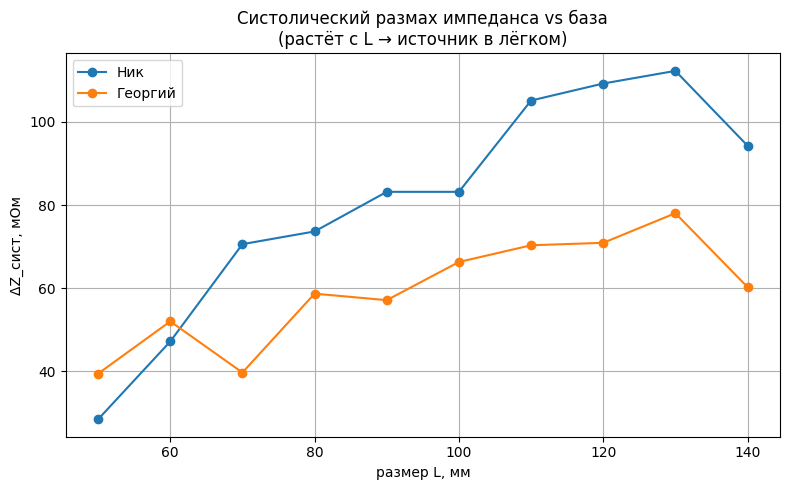

In [10]:
# @title График ΔZ_сист(L)
plt.figure(figsize=(8, 5))
for name in SUBJECTS:
    plt.plot(SIZES, [ENS[name][s]["dZ"]*1000 for s in SIZES], "o-", label=name)
plt.xlabel("размер L, мм"); plt.ylabel("ΔZ_сист, мОм")
plt.title("Систолический размах импеданса vs база\n(растёт с L → источник в лёгком)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## §3. Разделение Δρ₁, Δρ₂ (ур. 11)

`ΔZ_сист(L) = ∂Z/∂ρ₁·Δρ₁ + ∂Z/∂ρ₂·Δρ₂` — линейно по Δρ. Решаем МНК по всем размерам. Знак: кровенаполнение снижает ρ (Δρ — это спад), здесь — модуль размаха.

In [11]:
# @title Линейный МНК Δρ1, Δρ2 + проекция (только ρ2)
print("%-8s | Δρ1     Δρ2     | проекция ρ2 | спред углов | трактовка" % "субъект")
print("-"*86)
for name, info in SUBJECTS.items():
    r1, r2, h = info["rho1"], info["rho2"], info["h"]
    J  = np.array([[dZ_drho1(r1, r2, h, *ab(s)), dZ_drho2(r1, r2, h, *ab(s))] for s in SIZES])
    dZ = np.array([ENS[name][s]["dZ"] for s in SIZES])
    sol, *_ = np.linalg.lstsq(J, dZ, rcond=None)
    proj = np.median(dZ / J[:, 1])                       # Δρ2 при Δρ1=0
    angs = [np.degrees(np.arctan2(J[k,1], J[k,0])) for k in range(len(SIZES))]
    spread = max(angs) - min(angs)
    note = "разделение надёжно" if spread > 12 else "split ненадёжен (см. §4.4) → брать проекцию"
    print("%-8s | %6.3f  %6.3f | %6.3f      | %5.1f°      | %s"
          % (name, sol[0], sol[1], proj, spread, note))
print("\nΔρ2≈0.07–0.09 Ом·м (~0.4%% от ρ2): пульсовое кровенаполнение лёгкого. Δρ1≈0: мягкие ткани почти не пульсируют.")

субъект  | Δρ1     Δρ2     | проекция ρ2 | спред углов | трактовка
--------------------------------------------------------------------------------------
Ник      | -0.002   0.085 |  0.066      |   9.0°      | split ненадёжен (см. §4.4) → брать проекцию
Георгий  |  0.002   0.073 |  0.098      |   9.3°      | split ненадёжен (см. §4.4) → брать проекцию

Δρ2≈0.07–0.09 Ом·м (~0.4%% от ρ2): пульсовое кровенаполнение лёгкого. Δρ1≈0: мягкие ткани почти не пульсируют.


## §3.1. Почему Δρ₁≈0: форма сигнала несовместима с мягкими тканями

`∂Z/∂ρ₁` убывает с размером решётки, `∂Z/∂ρ₂` растёт. Измеренный `ΔZ_сист(L)` растёт → источник в лёгком. Подгонка только базисом ρ₁ даёт R²<0 (форма принципиально не та), только ρ₂ — хорошо. Это и есть обоснование Δρ₁≈0 (§4.6 документа 06).

субъект  | R² (ρ1-only) | R² (ρ2-only) | угол L-форм базисов
------------------------------------------------------------
Ник      |    -2.45     |    +0.76     | 27°
Георгий  |    -5.66     |    -0.11     | 41°


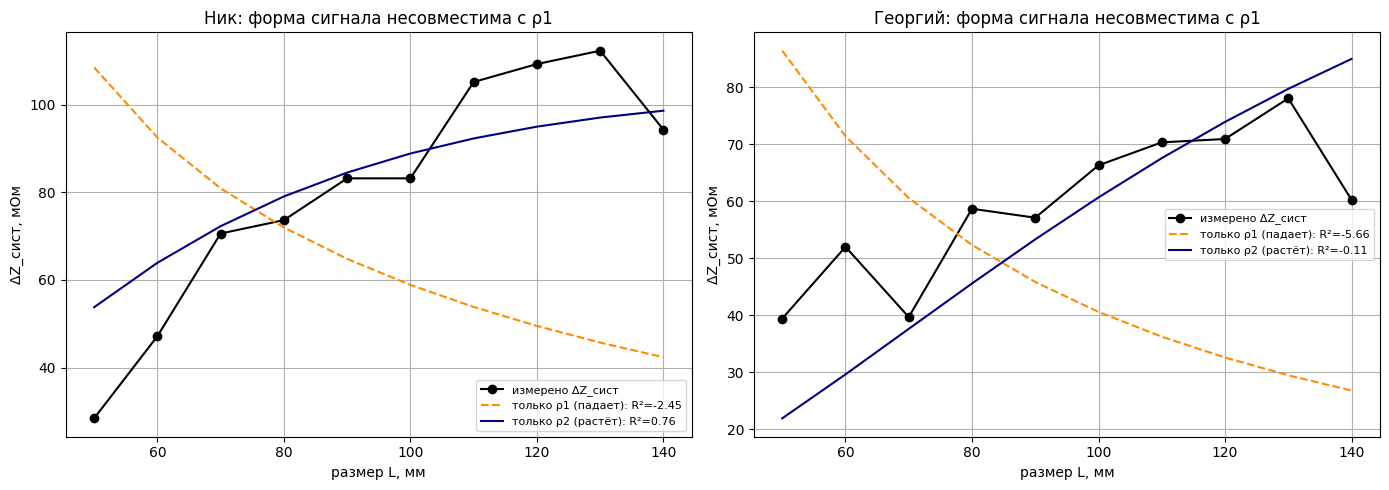

Сигнал растёт с L → лёгкое (ρ2). Мягкотканный базис (ρ1, убывающий) даёт R²<0 → Δρ1≈0 обоснован.


In [5]:
# @title Подгонка ρ1-only vs ρ2-only (обоснование Δρ1≈0)
fig, ax = plt.subplots(1, len(SUBJECTS), figsize=(7*len(SUBJECTS), 5), squeeze=False)
print("%-8s | R² (ρ1-only) | R² (ρ2-only) | угол L-форм базисов" % "субъект")
print("-"*60)
for j, (name, info) in enumerate(SUBJECTS.items()):
    r1, r2, h = info["rho1"], info["rho2"], info["h"]
    dZ = np.array([ENS[name][s]["dZ"] for s in SIZES])
    J1 = np.array([dZ_drho1(r1, r2, h, *ab(s)) for s in SIZES])
    J2 = np.array([dZ_drho2(r1, r2, h, *ab(s)) for s in SIZES])
    a1 = np.dot(dZ, J1)/np.dot(J1, J1); a2 = np.dot(dZ, J2)/np.dot(J2, J2)
    R2 = lambda res: 1 - np.sum(res**2)/np.sum((dZ-dZ.mean())**2)
    r2_1, r2_2 = R2(dZ-a1*J1), R2(dZ-a2*J2)
    ang = np.degrees(np.arccos(np.dot(J1, J2)/(np.linalg.norm(J1)*np.linalg.norm(J2))))
    print("%-8s |    %+5.2f     |    %+5.2f     | %.0f°" % (name, r2_1, r2_2, ang))
    a = ax[0][j]
    a.plot(SIZES, dZ*1000,    "ko-", label="измерено ΔZ_сист")
    a.plot(SIZES, a1*J1*1000, "--", color="darkorange", label="только ρ1 (падает): R²=%.2f" % r2_1)
    a.plot(SIZES, a2*J2*1000, "-",  color="navy",       label="только ρ2 (растёт): R²=%.2f" % r2_2)
    a.set_xlabel("размер L, мм"); a.set_ylabel("ΔZ_сист, мОм")
    a.set_title("%s: форма сигнала несовместима с ρ1" % name); a.legend(fontsize=8); a.grid(True)
plt.tight_layout(); plt.show()
print("Сигнал растёт с L → лёгкое (ρ2). Мягкотканный базис (ρ1, убывающий) даёт R²<0 → Δρ1≈0 обоснован.")

## §3.2. Численная граница Δρ₁ по самой малой решётке

Мелкая решётка (L=50) максимально поверхностна — лучший пробник ρ₁. Из её ΔZ_сист вычитаем вклад лёгкого (Δρ₂ с крупных баз), остаток → Δρ₁. Неопределённость — бутстреп по ударам. Ответ — **граница**, а не значение (§4.7 документа 06).

субъект  | ΔZ_сист(50)   | Δρ1 верх.гран. | Δρ1 остаток        | Δρ2/ρ2
------------------------------------------------------------------------------
Ник      | 28.4±7.7 мОм | 1.56 мОм·м (0.033%) | -1.80±0.42 мОм·м (-0.038%) | 0.45%
Георгий  | 39.4±7.5 мОм | 2.35 мОм·м (0.018%) | +1.07±0.45 мОм·м (+0.008%) | 0.48%


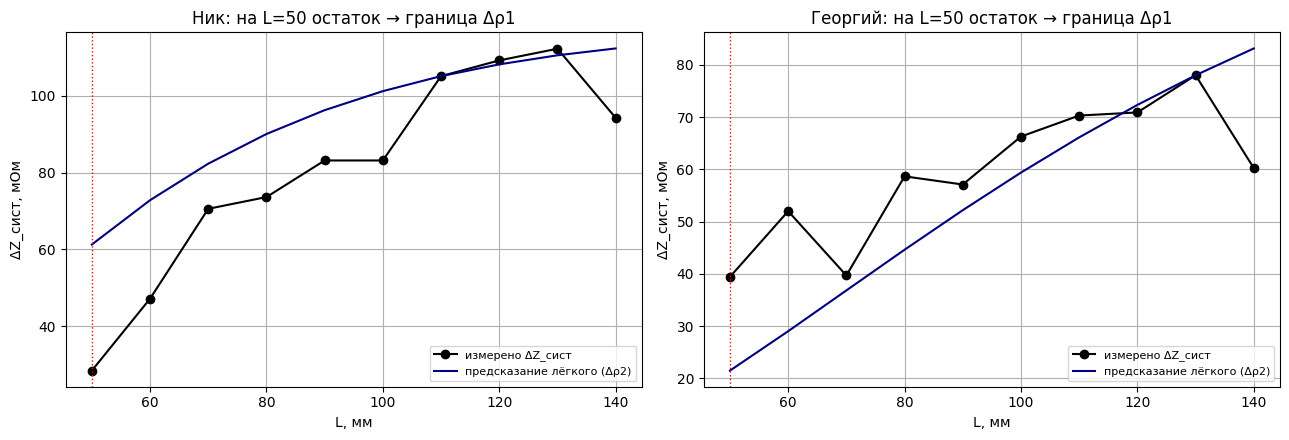

Δρ1 разного знака между испытуемыми и |Δρ1|<~0.05%·ρ1 → согласуется с нулём (граница, не значение).


In [6]:
# @title Граница Δρ1 из L=50 (бутстреп)
import numpy as _np
def _segs(name, L):
    info = SUBJECTS[name]
    df = pd.read_csv(os.path.join(info["dir"], "%d%s.csv" % (L, info["pat"])), encoding="utf-8")
    fs = 1.0/_np.median(_np.diff(df["TIME_s"].values))
    rec = json.load(open(os.path.join(TS_DIR, "%d%s.json" % (L, info["pat"])), encoding="utf-8"))
    R = _np.array(rec["rpeaks_s"]); ip, ipo = int(PRE*fs), int(POST*fs)
    x = df[RHEO_COL].values; segs = []
    for r in R:
        i = int(r*fs)
        if i-ip >= 0 and i+ipo < len(x):
            s = x[i-ip:i+ipo]
            if _np.mean(_np.abs(_np.abs(s)-RAIL) < 0.5) > 0.02: continue
            segs.append(s)
    return _np.array(segs)
_amp = lambda segs: (segs.mean(0).max() - segs.mean(0).min())/1000.0   # Ом

rng = _np.random.default_rng(0)
print("%-8s | ΔZ_сист(50)   | Δρ1 верх.гран. | Δρ1 остаток        | Δρ2/ρ2" % "субъект")
print("-"*78)
for name, info in SUBJECTS.items():
    r1, r2, h = info["rho1"], info["rho2"], info["h"]
    # Δρ2 по крупным базам
    big = [_amp(_segs(name, L))/dZ_drho2(r1, r2, h, *ab(L)) for L in [100,110,120,130,140]]
    dr2 = _np.median(big)
    segs = _segs(name, 50); nb_ = len(segs); dZ50 = _amp(segs)
    J1, J2 = dZ_drho1(r1, r2, h, *ab(50)), dZ_drho2(r1, r2, h, *ab(50))
    boot = _np.array([_amp(segs[rng.integers(0, nb_, nb_)]) for _ in range(400)])
    dr1_res = (dZ50 - J2*dr2)/J1
    dr1_se  = ((boot - J2*dr2)/J1).std()
    dr1_ub  = dZ50/J1
    print("%-8s | %4.1f±%.1f мОм | %.2f мОм·м (%.3f%%) | %+.2f±%.2f мОм·м (%+.3f%%) | %.2f%%"
          % (name, dZ50*1000, boot.std()*1000, dr1_ub*1000, dr1_ub/r1*100,
             dr1_res*1000, dr1_se*1000, dr1_res/r1*100, dr2/r2*100))

# график: измерено vs предсказание лёгкого на малой базе
fig, ax = plt.subplots(1, len(SUBJECTS), figsize=(6.5*len(SUBJECTS), 4.5), squeeze=False)
for j, (name, info) in enumerate(SUBJECTS.items()):
    r1, r2, h = info["rho1"], info["rho2"], info["h"]
    dr2 = _np.median([_amp(_segs(name, L))/dZ_drho2(r1, r2, h, *ab(L)) for L in [100,110,120,130,140]])
    meas = _np.array([_amp(_segs(name, L))*1000 for L in SIZES])
    pred = _np.array([dZ_drho2(r1, r2, h, *ab(L))*dr2*1000 for L in SIZES])   # только лёгкое
    a = ax[0][j]
    a.plot(SIZES, meas, "ko-", label="измерено ΔZ_сист")
    a.plot(SIZES, pred, "-", color="navy", label="предсказание лёгкого (Δρ2)")
    a.axvline(50, color="red", ls=":", lw=1); a.set_title("%s: на L=50 остаток → граница Δρ1" % name)
    a.set_xlabel("L, мм"); a.set_ylabel("ΔZ_сист, мОм"); a.legend(fontsize=8); a.grid(True)
plt.tight_layout(); plt.show()
print("Δρ1 разного знака между испытуемыми и |Δρ1|<~0.05%·ρ1 → согласуется с нулём (граница, не значение).")

## §3.3. Time-resolved Δρ₁(t), Δρ₂(t) — максимально точная оценка и её предел

В каждый момент сердечного цикла решается GLS по всем 10 решёткам (веса = 1/SE² ансамбля): `ΔZ_k(t)=∂Z/∂ρ₁·Δρ₁(t)+∂Z/∂ρ₂·Δρ₂(t)`. Это лучшее использование данных. **Δρ₂(t)** — надёжен (узкая полоса). **Δρ₁(t)** формально ненулевой, но: у Ника со-временен Δρ₂ (пик ~325 мс ≈ пик Δρ₂ → протекание модели), у Георга шумовой; знак метод-зависим. То есть это систематика модели, а не отдельный источник. Полосы — только статистический шум; реальный предел Δρ₁ — модельный (§4.8 документа 06).

In [ ]:
# @title Time-resolved Δρ1(t), Δρ2(t): GLS по решёткам в каждый момент
TG = np.arange(-0.10, 0.50, 0.005)     # время относительно R, с

def _waveforms(info):
    W = np.zeros((len(SIZES), len(TG))); SE = np.zeros_like(W)
    for ki, L in enumerate(SIZES):
        df, fs, R, rec = load_record(info, L)
        x = df[RHEO_COL].values; t = df["TIME_s"].values; segs = []
        for r in R:
            s = np.interp(r + TG, t, x)
            if np.mean(np.abs(np.abs(s) - RAIL) < 0.5) > 0.02: continue   # отбраковка клиппинга
            segs.append(s - s[TG < 0].mean())                              # baseline = до R
        segs = np.array(segs)
        W[ki]  = segs.mean(0)/1000.0                                       # Ом
        SE[ki] = segs.std(0)/1000.0/np.sqrt(len(segs))                     # SE среднего
    return W, SE

fig, ax = plt.subplots(2, len(SUBJECTS), figsize=(7*len(SUBJECTS), 8), squeeze=False, sharex=True)
print("%-8s | пик Δρ2: t / значение±SE / %%ρ2 | Δρ1 в этот t ±SE / %%ρ1 | t(пик|Δρ1|)" % "субъект")
print("-"*96)
for j, (name, info) in enumerate(SUBJECTS.items()):
    r1, r2, h = info["rho1"], info["rho2"], info["h"]
    J = np.array([[dZ_drho1(r1,r2,h,*ab(L)), dZ_drho2(r1,r2,h,*ab(L))] for L in SIZES])
    W, SE = _waveforms(info)
    dr1 = np.zeros(len(TG)); dr2 = np.zeros(len(TG)); s1 = np.zeros(len(TG)); s2 = np.zeros(len(TG))
    for it in range(len(TG)):
        Wm = np.diag(1.0/np.maximum(SE[:,it], 1e-4)**2)
        cov = np.linalg.inv(J.T@Wm@J); x = cov@J.T@Wm@W[:,it]
        dr1[it], dr2[it] = x; s1[it], s2[it] = np.sqrt(np.diag(cov))
    ip = int(np.argmax(np.abs(dr2))); ip1 = int(np.argmax(np.abs(dr1)))
    print("%-8s | %.0fмс / %+.3f±%.3f / %+.2f%% | %+.4f±%.4f / %+.3f%% | %.0fмс"
          % (name, TG[ip]*1000, dr2[ip], s2[ip], dr2[ip]/r2*100,
             dr1[ip], s1[ip], dr1[ip]/r1*100, TG[ip1]*1000))
    a0 = ax[0][j]
    a0.plot(TG*1000, dr2*1000, color="navy")
    a0.fill_between(TG*1000, (dr2-2*s2)*1000, (dr2+2*s2)*1000, color="navy", alpha=0.2)
    a0.axhline(0, color="0.7", lw=0.6); a0.axvline(TG[ip]*1000, color="red", ls=":", lw=1)
    a0.set_title("%s: Δρ2(t) — пик %+.0f мОм·м @ %.0f мс (надёжно)" % (name, dr2[ip]*1000, TG[ip]*1000))
    a0.set_ylabel("Δρ2, мОм·м"); a0.grid(True)
    a1 = ax[1][j]
    a1.plot(TG*1000, dr1*1000, color="darkorange")
    a1.fill_between(TG*1000, (dr1-2*s1)*1000, (dr1+2*s1)*1000, color="darkorange", alpha=0.2)
    a1.axhline(0, color="0.7", lw=0.6); a1.axvline(TG[ip]*1000, color="red", ls=":", lw=1, label="пик Δρ2")
    a1.set_title("%s: Δρ1(t) — со-временен Δρ2 → протекание модели (не сигнал)" % name)
    a1.set_ylabel("Δρ1, мОм·м"); a1.set_xlabel("время от R, мс"); a1.legend(fontsize=8); a1.grid(True)
plt.tight_layout(); plt.show()
print("ИТОГ: Δρ2 ≈ -0.08 Ом·м (пик ~340 мс), точность ~10%% (статистика).")
print("      Δρ1 со-временен Δρ2 и метод-зависим -> систематика модели; |Δρ1| ≲ 2 мОм·м (≲0.05%% ρ1) — ГРАНИЦА, не значение.")
print("      Полосы = ТОЛЬКО статистический шум; реальный предел Δρ1 — модельная систематика (§4.8 док. 06).")

## §4. Электромеханическая задержка

Из ансамблевой волны: начало спада импеданса (электромеханическая задержка от R) и провал (пик наполнения). Сравниваем с окном электрической систолы из меток (Q≈R−40 мс … T_end по Базетту).

субъект  | R->начало спада | R->пик наполнения | конец эл.систолы (QT, Базетт)
------------------------------------------------------------------------------------
Ник      |    117 мс       |      330 мс        |    408 мс
Георгий  |    192 мс       |      320 мс        |    362 мс


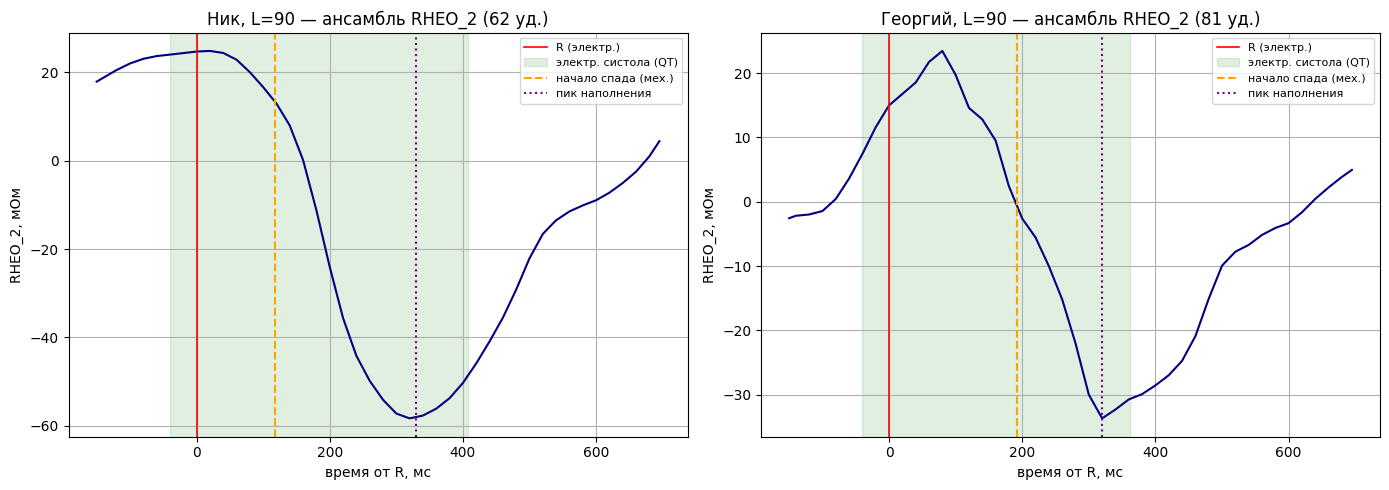

In [7]:
# @title Задержки + ансамблевая волна с разметкой систолы
def mech_markers(avg, t):
    drift = np.gradient(avg)
    base = avg[t < 0].mean() if (t < 0).any() else avg[0]
    onset_i = next((i for i in range(len(t)) if t[i] >= 0 and avg[i] < base - 0.1*(base-avg.min())), np.argmin(avg))
    return t[onset_i], t[np.argmin(avg)]      # начало спада, провал

print("%-8s | R->начало спада | R->пик наполнения | конец эл.систолы (QT, Базетт)" % "субъект")
print("-"*84)
SHOW = 90
fig, ax = plt.subplots(1, len(SUBJECTS), figsize=(7*len(SUBJECTS), 5), squeeze=False)
for j, (name, info) in enumerate(SUBJECTS.items()):
    on, tr = [], []
    for s in SIZES:
        o, t_ = mech_markers(ENS[name][s]["avg"], ENS[name][s]["t"]); on.append(o); tr.append(t_)
    df, fs, R, rec = load_record(info, SHOW)
    rr = np.median(np.diff(R)); qt = 0.40*np.sqrt(rr)
    print("%-8s |   %4.0f мс       |     %4.0f мс        |   %4.0f мс"
          % (name, np.median(on)*1000, np.median(tr)*1000, qt*1000))
    a = ax[0][j]; E = ENS[name][SHOW]
    a.plot(E["t"]*1000, E["avg"], color="navy")
    a.axvline(0, color="red", lw=1.2, label="R (электр.)")
    a.axvspan(-40, qt*1000, color="green", alpha=0.12, label="электр. систола (QT)")
    a.axvline(np.median(on)*1000, color="orange", ls="--", label="начало спада (мех.)")
    a.axvline(np.median(tr)*1000, color="purple", ls=":", label="пик наполнения")
    a.set_title("%s, L=%d — ансамбль RHEO_2 (%d уд.)" % (name, SHOW, E["nbeats"]))
    a.set_xlabel("время от R, мс"); a.set_ylabel("RHEO_2, мОм"); a.legend(fontsize=8); a.grid(True)
plt.tight_layout(); plt.show()

## §5. Выводы

- Сердечная пульсация лёгочного канала **сосредоточена в ρ₂** (Δρ₁≈0): это кровенаполнение лёгкого, Δρ₂≈0.07–0.09 Ом·м (спад, ~0.4% от ρ₂).
- Разделение Δρ₁/Δρ₂ надёжно при тонких тканях; для Георга наследует плохую обусловленность (§2.4, §4.4) — там брать проекцию (ρ₂-доминанта).
- Пик наполнения лёгкого наступает ≈320–340 мс после R — электромеханическая задержка + транзит пульсовой волны; укладывается в окно электрической систолы.
- ⚠ Единицы `RHEO_2` (мОм) приняты как истинный ΔZ; калибровку прибора (gain/производная) подтвердить. Разделение требует воспроизводимости сердечного отклика между записями (§4.4).
- Дальше: сверка задержки/Δρ по **механической** систоле из реограммы vs электрической; перевод Δρ₂→Δобъём крови через модель смешивания (§3.2).